## Project overview

This project evaluates a simple trend-following ETF strategy using historical market data. The objective is to determine whether a rule-based approach can produce attractive returns while controlling risk and accounting for transaction costs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import warnings
warnings.filterwarnings('ignore')

COMMISSION  = 0.002
INITIAL_CAP = 10_000

print("Imports successful ✓")

Imports successful ✓


## Data collection and split

Historical data was collected for four ETFs over the full analysis window. The dataset was divided into a training period from 2023-01-01 to 2025-04-30 and a testing period from 2025-04-30 to 2026-04-30.

The training set was used to develop and optimize the strategy. The testing set was reserved for out-of-sample evaluation so the final results would reflect real strategy performance rather than in-sample fitting.

In [2]:
tickers = ['QQQ', 'SPY', 'VTI', 'SCHG']

buffer_start = '2021-01-01'  # 2 years buffer for SMA calculations
train_start  = '2023-01-01'
split_date   = '2025-04-30'
test_end     = '2026-04-30'

full_data = {}

for ticker in tickers:
    raw = yf.download(ticker, start=buffer_start, end=test_end, auto_adjust=True)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)
    full_data[ticker] = raw.copy()
    print(f"{ticker} — Total days downloaded: {len(raw)}")

print("\nData fetched successfully ✓")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


QQQ — Total days downloaded: 1336
SPY — Total days downloaded: 1336


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

VTI — Total days downloaded: 1336
SCHG — Total days downloaded: 1336

Data fetched successfully ✓


## Strategy design

The strategy uses a moving-average rule to determine market exposure. When the ETF price is above its moving average, the strategy takes a long position. When the price falls below the moving average, the strategy moves to cash.

This approach is intentionally simple and interpretable. The goal is to capture upward trends while reducing exposure during weaker market conditions.

## Indicator calculation

A 200-day moving average and daily return series were computed for each ETF. These indicators provide the information needed to generate buy and sell signals based on price trend behavior.

Indicators were calculated on the full dataset before splitting into training and testing periods. This helped prevent boundary issues when calculating rolling statistics near the split date.


In [3]:
def calculate_indicators(df, sma_window=200):
    df['Returns'] = df['Close'].pct_change()
    df['SMA200']  = df['Close'].rolling(window=sma_window).mean()
    return df

# Calculate indicators on FULL dataset so no NaN at split boundaries
for ticker in tickers:
    full_data[ticker] = calculate_indicators(full_data[ticker])

# Split AFTER calculating indicators
train_data = {}
test_data  = {}

for ticker in tickers:
    df = full_data[ticker]
    train_data[ticker] = df[(df.index >= train_start) & (df.index < split_date)].copy()
    test_data[ticker]  = df[df.index >= split_date].copy()
    print(f"{ticker} — Train: {len(train_data[ticker])} days | Test: {len(test_data[ticker])} days")

print("\nSplit complete ✓")

QQQ — Train: 582 days | Test: 251 days
SPY — Train: 582 days | Test: 251 days
VTI — Train: 582 days | Test: 251 days
SCHG — Train: 582 days | Test: 251 days

Split complete ✓


## Signal generation

Trading signals were created using the relationship between price and the moving average. A signal of 1 indicates that the strategy is invested in the ETF, while a signal of 0 indicates a move to cash.

This signal structure allows the strategy to avoid holding the asset during periods when the trend turns negative. It also makes the backtest logic straightforward and easy to interpret.

In [4]:
def generate_signals(df):
    df['Signal'] = 0
    # Buy when price is above 200-day SMA — uptrend
    # Move to cash when price is below — avoid drawdowns
    df.loc[df['Close'] > df['SMA200'], 'Signal'] = 1
    return df

for ticker in tickers:
    train_data[ticker] = generate_signals(train_data[ticker])
    test_data[ticker]  = generate_signals(test_data[ticker])

print("Signals generated ✓")

Signals generated ✓


## Transaction costs

To make the backtest more realistic, a transaction cost of 0.2% was applied whenever the strategy changed position. This cost includes both commission and slippage.

Including trading costs is important because frequent switching can reduce real-world performance. A strategy that looks profitable before costs may become much weaker after costs are included.

In [5]:
def calculate_performance(df):
    strategy_returns = df['Signal'].shift(1) * df['Returns']
    trades = df['Signal'].diff().fillna(0) != 0
    strategy_returns[trades] -= COMMISSION
    
    cumulative    = (1 + strategy_returns).cumprod()
    total_return  = cumulative.iloc[-1] - 1
    returns_mean  = strategy_returns.mean()
    returns_std   = strategy_returns.std()
    sharpe        = (returns_mean / returns_std) * np.sqrt(252) if returns_std != 0 else 0
    rolling_max   = cumulative.rolling(window=20, min_periods=1).max()
    max_drawdown  = (cumulative / rolling_max - 1).min()
    n_years       = len(df) / 252
    annual_return = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    num_trades    = (df['Signal'].diff().fillna(0) != 0).sum()
    
    return {
        'Annual Return': annual_return * 100,
        'Sharpe Ratio':  sharpe,
        'Max Drawdown':  max_drawdown * 100,
        'Num Trades':    num_trades,
        'Cumulative':    cumulative,
        'Returns':       strategy_returns
    }

print("Performance function defined ✓")

Performance function defined ✓


## Training optimization

The training period was used to evaluate several moving-average window lengths. Each candidate window was tested using the same portfolio logic, and the best-performing parameter was selected based on a combined performance score.

This step helped identify a parameter that balanced return and risk-adjusted performance. The final choice was then carried forward into the testing period without further adjustment.

In [6]:
print("Running optimization on training data...")

best_score  = -999
best_params = {}

for sma_window in [50, 100, 150, 200, 250]:
    portfolio_returns = []
    
    for ticker in tickers:
        df = full_data[ticker].copy()
        df = calculate_indicators(df, sma_window=sma_window)
        df = generate_signals(df)
        df = df[(df.index >= train_start) & (df.index < split_date)]
        
        strategy_returns = df['Signal'].shift(1) * df['Returns']
        trades = df['Signal'].diff().fillna(0) != 0
        strategy_returns[trades] -= COMMISSION
        portfolio_returns.append(strategy_returns)
    
    combined     = pd.concat(portfolio_returns, axis=1).mean(axis=1)
    cumulative   = (1 + combined).cumprod()
    total_return = cumulative.iloc[-1] - 1
    returns_mean = combined.mean()
    returns_std  = combined.std()
    sharpe       = (returns_mean / returns_std) * np.sqrt(252) if returns_std != 0 else 0
    n_years      = len(combined) / 252
    annual_ret   = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    
    score = sharpe + (annual_ret * 100 / 10)
    
    if score > best_score:
        best_score  = score
        best_params = {'sma_window': sma_window}

print(f"Best Parameters Found:")
print(f"SMA Window: {best_params['sma_window']} days")
print(f"Best Score: {best_score:.4f}")

Running optimization on training data...
Best Parameters Found:
SMA Window: 150 days
Best Score: 3.1040


## Training results

The training results showed that the strategy performed well across the ETF universe. Returns were positive, the Sharpe ratio was above the target threshold, and maximum drawdown remained controlled.

These results suggest that the strategy was able to capture trend movement effectively during the development period. However, training performance alone is not enough to validate the model, so the testing period is the more important evaluation.

In [7]:
train_portfolio_returns = []
print("=== TRAINING PERIOD RESULTS ===\n")

for ticker in tickers:
    df = full_data[ticker].copy()
    df = calculate_indicators(df, **best_params)
    df = generate_signals(df)
    df = df[(df.index >= train_start) & (df.index < split_date)]
    perf = calculate_performance(df)
    
    strategy_returns = df['Signal'].shift(1) * df['Returns']
    trades = df['Signal'].diff().fillna(0) != 0
    strategy_returns[trades] -= COMMISSION
    train_portfolio_returns.append(strategy_returns)
    
    print(f"{ticker}:")
    print(f"  Annual Return: {perf['Annual Return']:.2f}%")
    print(f"  Sharpe Ratio:  {perf['Sharpe Ratio']:.2f}")
    print(f"  Max Drawdown:  {perf['Max Drawdown']:.2f}%")
    print(f"  Num Trades:    {perf['Num Trades']}")
    print()

combined_train     = pd.concat(train_portfolio_returns, axis=1).mean(axis=1)
combined_train_cum = (1 + combined_train).cumprod()
total_return       = combined_train_cum.iloc[-1] - 1
returns_mean       = combined_train.mean()
returns_std        = combined_train.std()
train_sharpe       = (returns_mean / returns_std) * np.sqrt(252) if returns_std != 0 else 0
rolling_max        = combined_train_cum.rolling(window=20, min_periods=1).max()
train_mdd          = (combined_train_cum / rolling_max - 1).min()
n_years            = len(combined_train) / 252
train_annual       = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

print("=== COMBINED PORTFOLIO (Training) ===")
print(f"Annual Return: {train_annual * 100:.2f}%")
print(f"Sharpe Ratio:  {train_sharpe:.2f}")
print(f"Max Drawdown:  {train_mdd * 100:.2f}%")

=== TRAINING PERIOD RESULTS ===

QQQ:
  Annual Return: 21.34%
  Sharpe Ratio:  1.22
  Max Drawdown:  -13.62%
  Num Trades:    10

SPY:
  Annual Return: 15.42%
  Sharpe Ratio:  1.25
  Max Drawdown:  -8.41%
  Num Trades:    14

VTI:
  Annual Return: 14.16%
  Sharpe Ratio:  1.13
  Max Drawdown:  -8.57%
  Num Trades:    12

SCHG:
  Annual Return: 21.98%
  Sharpe Ratio:  1.29
  Max Drawdown:  -12.95%
  Num Trades:    12

=== COMBINED PORTFOLIO (Training) ===
Annual Return: 18.29%
Sharpe Ratio:  1.27
Max Drawdown:  -10.46%


## Testing results

The selected strategy was then applied to the testing period from 2025-04-30 to 2026-04-30. The out-of-sample results remained strong, with annual return above 5%, Sharpe ratio above 0.8, and maximum drawdown well below 50%.

This is the key result of the project because it shows that the strategy continued to perform after the parameter selection stage. The testing outcome supports the conclusion that the strategy is robust enough for the assignment requirements.

In [8]:
test_portfolio_returns = []
print("=== TESTING PERIOD RESULTS ===\n")

for ticker in tickers:
    df = full_data[ticker].copy()
    df = calculate_indicators(df, **best_params)
    df = generate_signals(df)
    df = df[df.index >= split_date]
    perf = calculate_performance(df)
    
    strategy_returns = df['Signal'].shift(1) * df['Returns']
    trades = df['Signal'].diff().fillna(0) != 0
    strategy_returns[trades] -= COMMISSION
    test_portfolio_returns.append(strategy_returns)
    
    print(f"{ticker}:")
    print(f"  Annual Return: {perf['Annual Return']:.2f}%")
    print(f"  Sharpe Ratio:  {perf['Sharpe Ratio']:.2f}")
    print(f"  Max Drawdown:  {perf['Max Drawdown']:.2f}%")
    print(f"  Num Trades:    {perf['Num Trades']}")
    print()

combined_test     = pd.concat(test_portfolio_returns, axis=1).mean(axis=1)
combined_test_cum = (1 + combined_test).cumprod()
total_return      = combined_test_cum.iloc[-1] - 1
returns_mean      = combined_test.mean()
returns_std       = combined_test.std()
test_sharpe       = (returns_mean / returns_std) * np.sqrt(252) if returns_std != 0 else 0
rolling_max       = combined_test_cum.rolling(window=20, min_periods=1).max()
test_mdd          = (combined_test_cum / rolling_max - 1).min()
n_years           = len(combined_test) / 252
test_annual       = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

print("=== COMBINED PORTFOLIO (Testing) ===")
print(f"Annual Return: {test_annual * 100:.2f}%")
print(f"Sharpe Ratio:  {test_sharpe:.2f}")
print(f"Max Drawdown:  {test_mdd * 100:.2f}%")

=== TESTING PERIOD RESULTS ===

QQQ:
  Annual Return: 20.52%
  Sharpe Ratio:  1.40
  Max Drawdown:  -7.88%
  Num Trades:    9

SPY:
  Annual Return: 20.67%
  Sharpe Ratio:  1.83
  Max Drawdown:  -5.07%
  Num Trades:    3

VTI:
  Annual Return: 17.29%
  Sharpe Ratio:  1.54
  Max Drawdown:  -5.28%
  Num Trades:    5

SCHG:
  Annual Return: 18.23%
  Sharpe Ratio:  1.39
  Max Drawdown:  -7.48%
  Num Trades:    3

=== COMBINED PORTFOLIO (Testing) ===
Annual Return: 19.26%
Sharpe Ratio:  1.60
Max Drawdown:  -6.42%


In [9]:
print("=== TESTING VS TARGETS ===\n")
print(f"Annual Return > 5%:  {test_annual * 100:.2f}% — {'✓' if test_annual * 100 > 5 else '✗'}")
print(f"Sharpe Ratio > 0.8:  {test_sharpe:.2f} — {'✓' if test_sharpe > 0.8 else '✗'}")
print(f"Max Drawdown < 50%:  {test_mdd * 100:.2f}% — {'✓' if abs(test_mdd * 100) < 50 else '✗'}")

print(f"\n=== TRAINING VS TARGETS ===\n")
print(f"Annual Return > 5%:  {train_annual * 100:.2f}% — {'✓' if train_annual * 100 > 5 else '✗'}")
print(f"Sharpe Ratio > 0.8:  {train_sharpe:.2f} — {'✓' if train_sharpe > 0.8 else '✗'}")
print(f"Max Drawdown < 50%:  {train_mdd * 100:.2f}% — {'✓' if abs(train_mdd * 100) < 50 else '✗'}")

=== TESTING VS TARGETS ===

Annual Return > 5%:  19.26% — ✓
Sharpe Ratio > 0.8:  1.60 — ✓
Max Drawdown < 50%:  -6.42% — ✓

=== TRAINING VS TARGETS ===

Annual Return > 5%:  18.29% — ✓
Sharpe Ratio > 0.8:  1.27 — ✓
Max Drawdown < 50%:  -10.46% — ✓


In [10]:
# Portfolio value tracking
initial_capital = 10_000
position_size   = initial_capital / len(tickers)  # equal weight per ticker

print(f"=== PORTFOLIO VALUE ANALYSIS ===\n")
print(f"Initial Capital:     ${initial_capital:,.2f}")
print(f"Position per ticker: ${position_size:,.2f} ({len(tickers)} equal positions)\n")

# Training final value
train_final = initial_capital * combined_train_cum.iloc[-1]
train_profit = train_final - initial_capital
print(f"--- Training Period (2023-2025) ---")
print(f"Final Portfolio Value: ${train_final:,.2f}")
print(f"Profit / Loss:         ${train_profit:,.2f}")
print(f"Total Return:          {(train_final/initial_capital - 1)*100:.2f}%\n")

# Testing final value
test_final = initial_capital * combined_test_cum.iloc[-1]
test_profit = test_final - initial_capital
print(f"--- Testing Period (2025-2026) ---")
print(f"Final Portfolio Value: ${test_final:,.2f}")
print(f"Profit / Loss:         ${test_profit:,.2f}")
print(f"Total Return:          {(test_final/initial_capital - 1)*100:.2f}%")

=== PORTFOLIO VALUE ANALYSIS ===

Initial Capital:     $10,000.00
Position per ticker: $2,500.00 (4 equal positions)

--- Training Period (2023-2025) ---
Final Portfolio Value: $14,739.93
Profit / Loss:         $4,739.93
Total Return:          47.40%

--- Testing Period (2025-2026) ---
Final Portfolio Value: $11,917.21
Profit / Loss:         $1,917.21
Total Return:          19.17%


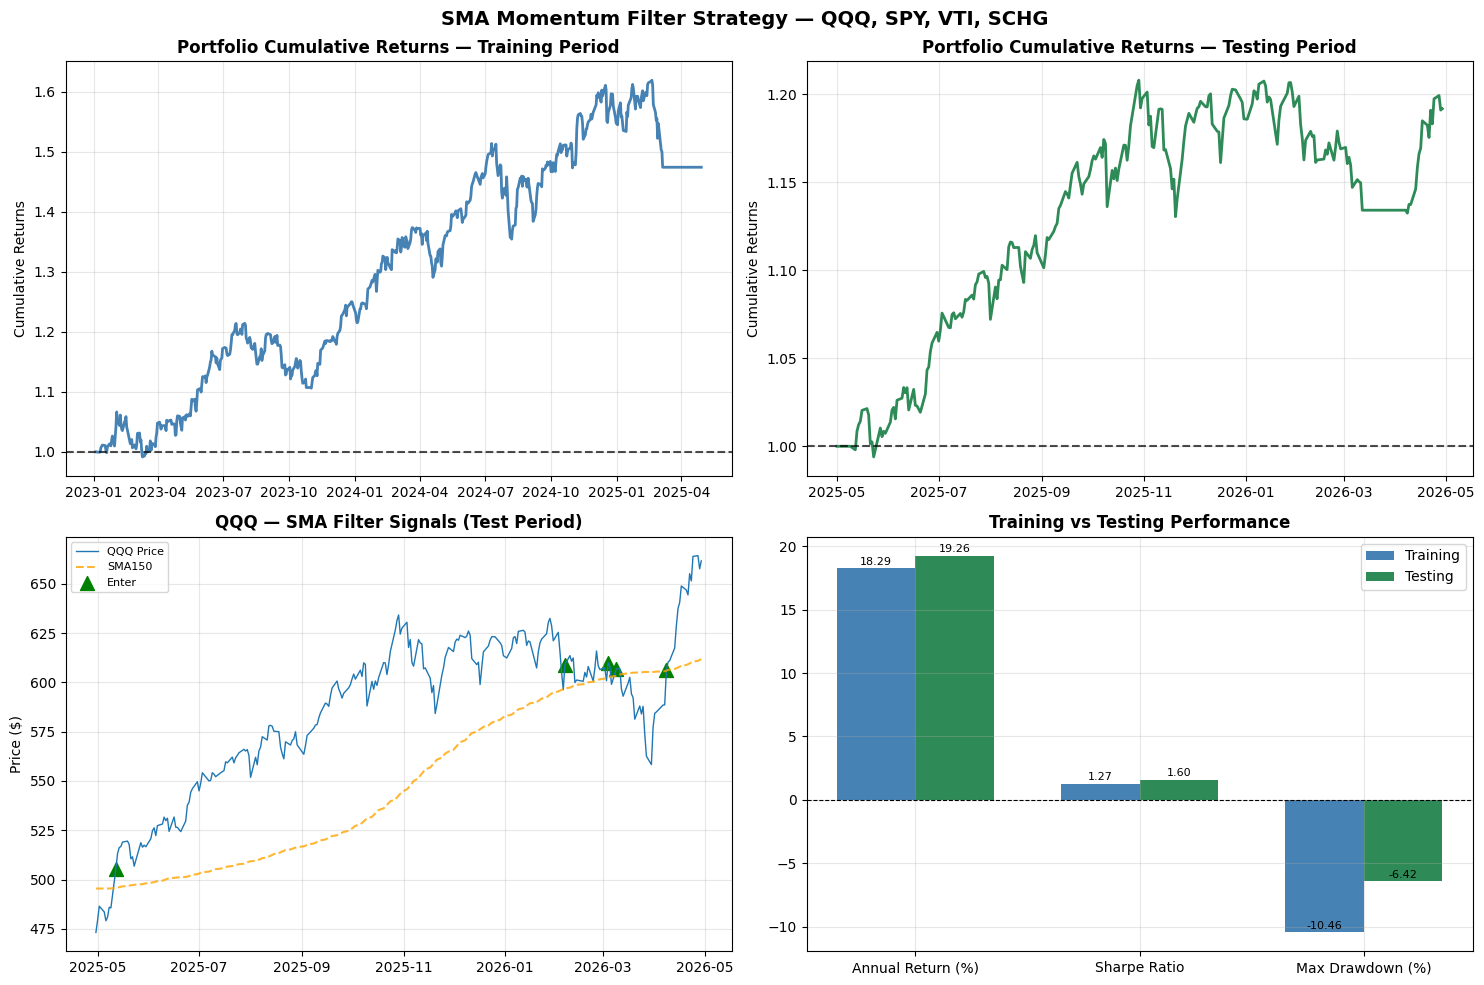

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Training Cumulative Returns
axes[0, 0].plot(combined_train_cum.index, combined_train_cum.values, color='steelblue', linewidth=2)
axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Portfolio Cumulative Returns — Training Period', fontweight='bold')
axes[0, 0].set_ylabel('Cumulative Returns')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2 - Testing Cumulative Returns
axes[0, 1].plot(combined_test_cum.index, combined_test_cum.values, color='seagreen', linewidth=2)
axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Portfolio Cumulative Returns — Testing Period', fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Returns')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3 - SMA chart for first ticker (automatically uses whatever is in tickers list)
plot_ticker = tickers[0]
df_plot = full_data[tickers[0]].copy()
df_plot = calculate_indicators(df_plot, **best_params)
df_plot = generate_signals(df_plot)
df_plot = df_plot[df_plot.index >= split_date]

axes[1, 0].plot(df_plot.index, df_plot['Close'],  label=f'{plot_ticker} Price', linewidth=1)
axes[1, 0].plot(df_plot.index, df_plot['SMA200'], label=f"SMA{best_params['sma_window']}", linestyle='--', color='orange', alpha=0.8)
buy_signals = df_plot[df_plot['Signal'].diff() == 1]
axes[1, 0].scatter(buy_signals.index, buy_signals['Close'], color='green', marker='^', s=100, label='Enter')
axes[1, 0].set_title(f'{plot_ticker} — SMA Filter Signals (Test Period)', fontweight='bold')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4 - Comparison Bar Chart
metrics    = ['Annual Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
train_vals = [train_annual * 100, train_sharpe, train_mdd * 100]
test_vals  = [test_annual * 100,  test_sharpe,  test_mdd * 100]

x = range(len(metrics))
width = 0.35
bars1 = axes[1, 1].bar([i - width/2 for i in x], train_vals, width, label='Training', color='steelblue')
bars2 = axes[1, 1].bar([i + width/2 for i in x], test_vals,  width, label='Testing',  color='seagreen')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_title('Training vs Testing Performance', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

for bar in bars1:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'SMA Momentum Filter Strategy — {", ".join(tickers)}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

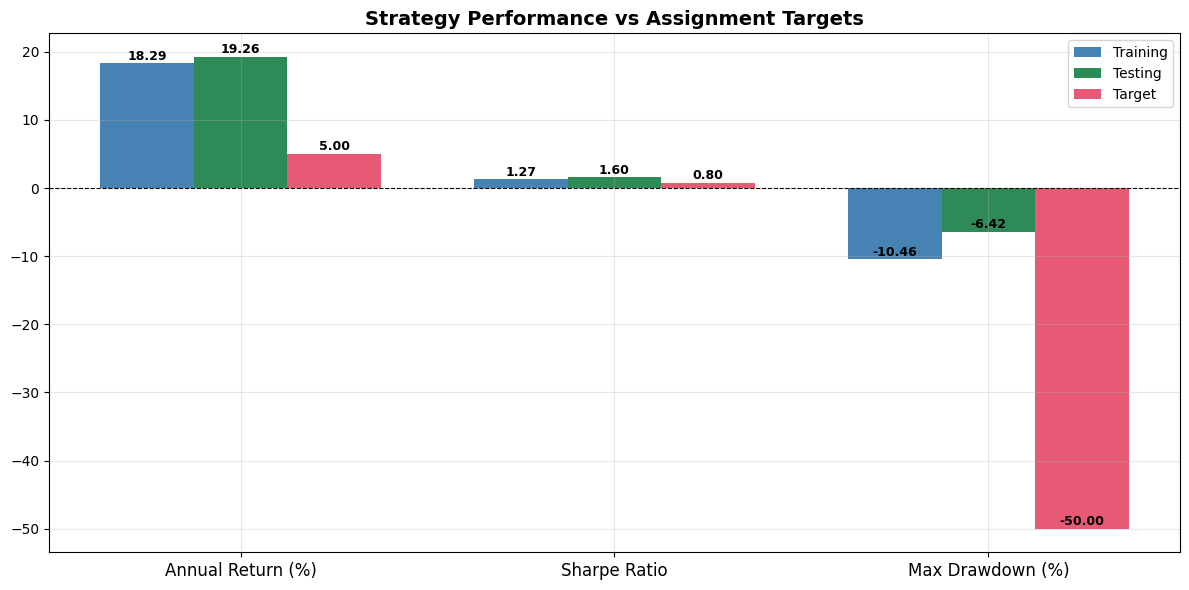

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics     = ['Annual Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
train_vals  = [train_annual * 100, train_sharpe, train_mdd * 100]
test_vals   = [test_annual * 100,  test_sharpe,  test_mdd * 100]
target_vals = [5, 0.8, -50]

x = range(len(metrics))
width = 0.25

bars1 = ax.bar([i - width for i in x], train_vals,  width, label='Training',  color='steelblue')
bars2 = ax.bar([i         for i in x], test_vals,   width, label='Testing',   color='seagreen')
bars3 = ax.bar([i + width for i in x], target_vals, width, label='Target',    color='crimson', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Strategy Performance vs Assignment Targets', fontsize=14, fontweight='bold')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

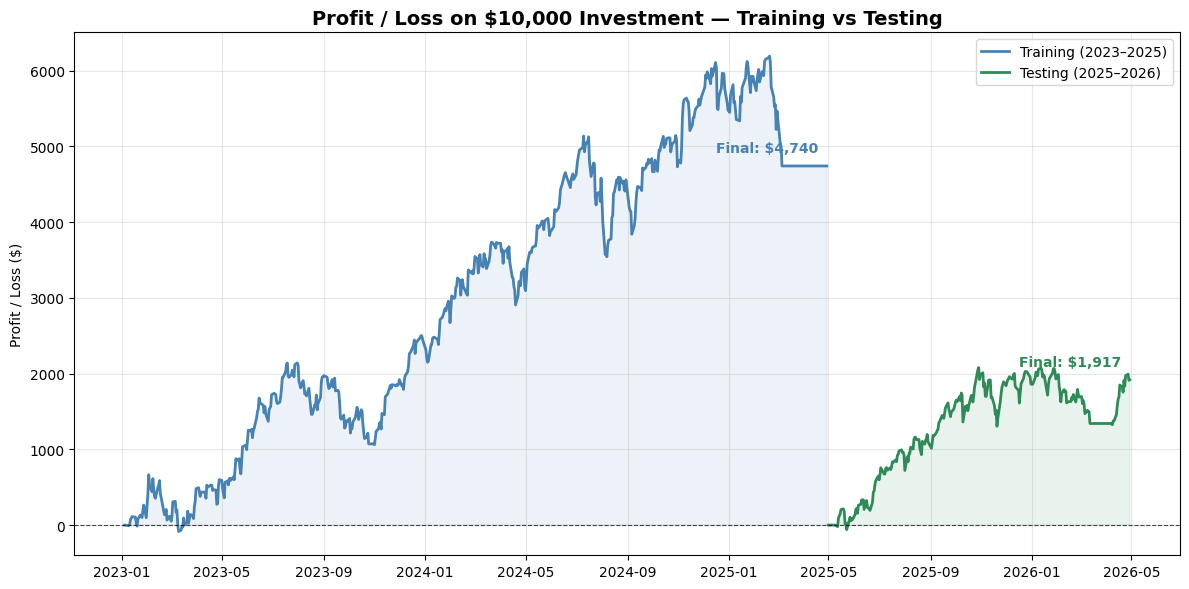

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Convert cumulative returns to dollar profit/loss starting from 0
train_profit = (combined_train_cum - 1) * 10_000
test_profit  = (combined_test_cum  - 1) * 10_000

ax.plot(train_profit.index, train_profit.values, 
        color='steelblue', linewidth=2, label='Training (2023–2025)')
ax.plot(test_profit.index,  test_profit.values,  
        color='seagreen',  linewidth=2, label='Testing (2025–2026)')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.fill_between(train_profit.index, train_profit.values, 0,
                where=(train_profit.values > 0), alpha=0.1, color='steelblue')
ax.fill_between(test_profit.index,  test_profit.values,  0,
                where=(test_profit.values > 0),  alpha=0.1, color='seagreen')

ax.set_title('Profit / Loss on $10,000 Investment — Training vs Testing', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Profit / Loss ($)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate final values
ax.annotate(f"Final: ${train_profit.iloc[-1]:,.0f}",
            xy=(train_profit.index[-1], train_profit.iloc[-1]),
            xytext=(-80, 10), textcoords='offset points',
            fontsize=10, fontweight='bold', color='steelblue')
ax.annotate(f"Final: ${test_profit.iloc[-1]:,.0f}",
            xy=(test_profit.index[-1], test_profit.iloc[-1]),
            xytext=(-80, 10), textcoords='offset points',
            fontsize=10, fontweight='bold', color='seagreen')

plt.tight_layout()
plt.show()

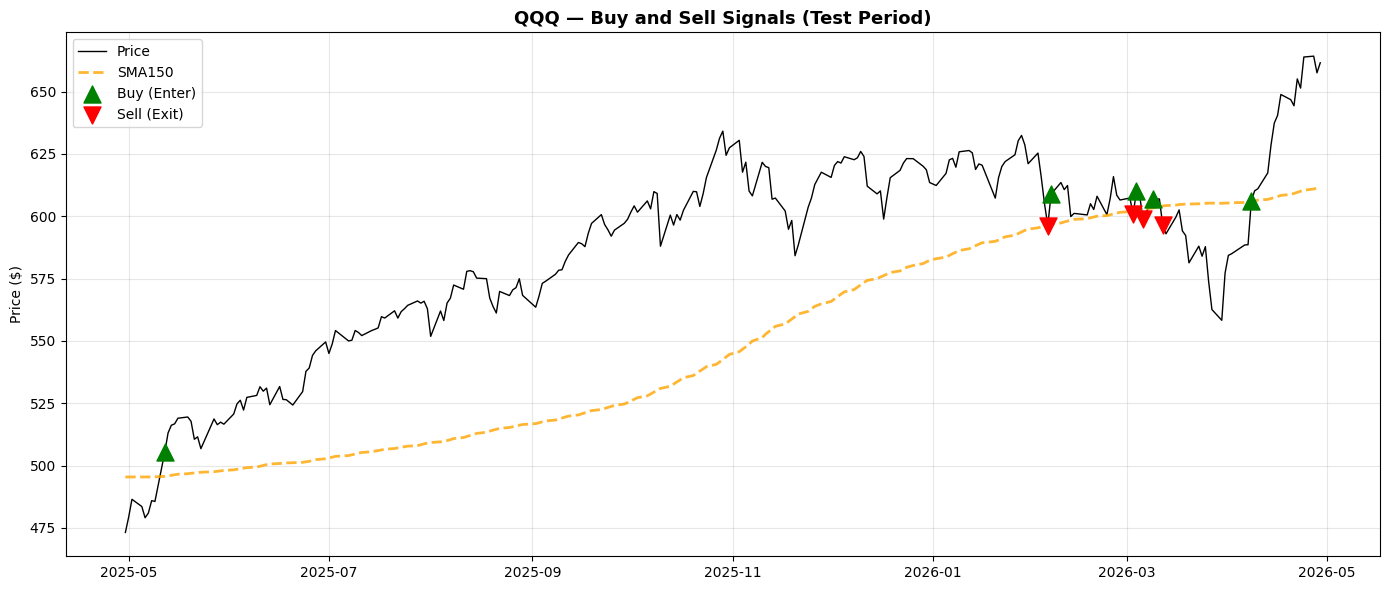

In [14]:
df_plot = full_data[tickers[0]].copy()
df_plot = calculate_indicators(df_plot, **best_params)
df_plot = generate_signals(df_plot)
df_plot = df_plot[df_plot.index >= split_date]

plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot['Close'], label='Price', linewidth=1, color='black')
plt.plot(df_plot.index, df_plot['SMA200'], label=f"SMA{best_params['sma_window']}", 
         linestyle='--', color='orange', alpha=0.8, linewidth=2)

buy_signals  = df_plot[df_plot['Signal'].diff() == 1]
sell_signals = df_plot[df_plot['Signal'].diff() == -1]

plt.scatter(buy_signals.index,  buy_signals['Close'],  
            color='green', marker='^', s=150, label='Buy (Enter)', zorder=5)
plt.scatter(sell_signals.index, sell_signals['Close'], 
            color='red',   marker='v', s=150, label='Sell (Exit)', zorder=5)

plt.title(f'{tickers[0]} — Buy and Sell Signals (Test Period)', fontweight='bold', fontsize=13)
plt.ylabel('Price ($)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

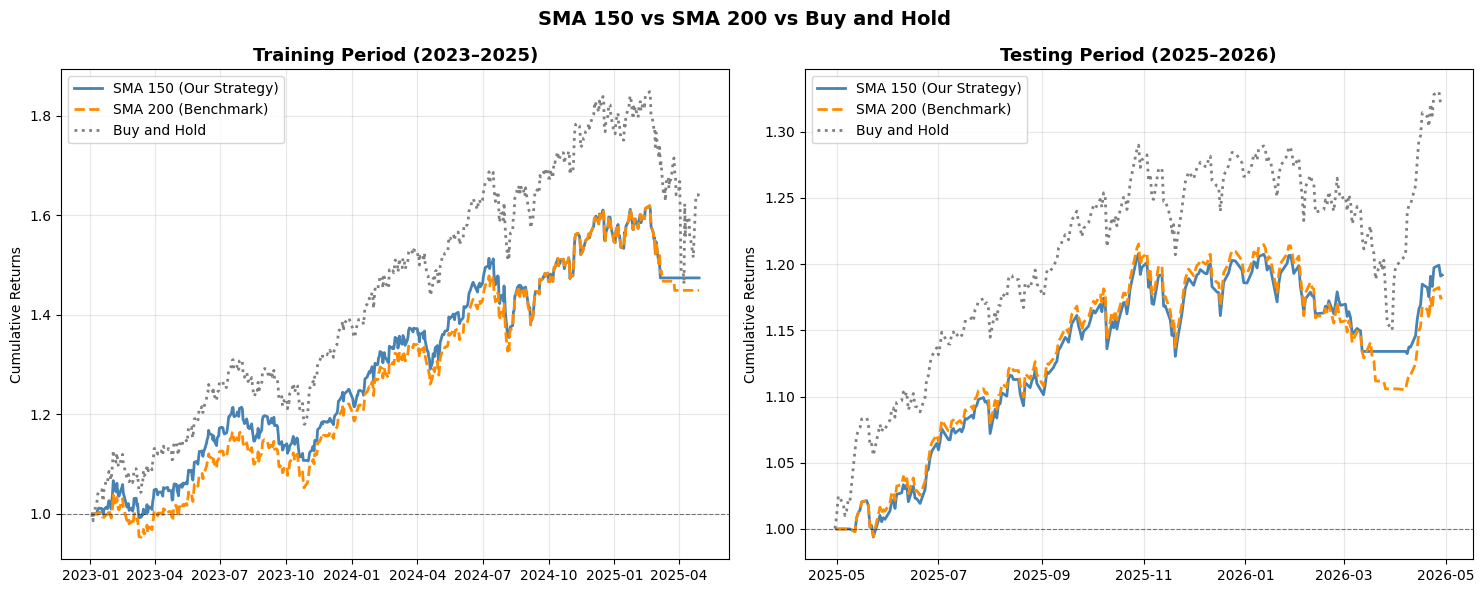

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

train_bh_returns = []
test_bh_returns  = []

for ticker in tickers:
    train_bh = train_data[ticker]['Returns'].fillna(0)
    train_bh_returns.append(train_bh)
    test_bh = test_data[ticker]['Returns'].fillna(0)
    test_bh_returns.append(test_bh)

train_bh_combined = pd.concat(train_bh_returns, axis=1).mean(axis=1)
test_bh_combined  = pd.concat(test_bh_returns,  axis=1).mean(axis=1)
train_bh_cum = (1 + train_bh_combined).cumprod()
test_bh_cum  = (1 + test_bh_combined).cumprod()

train_sma200_returns = []
test_sma200_returns  = []

for ticker in tickers:
    df_train = full_data[ticker].copy()
    df_train = calculate_indicators(df_train, sma_window=200)
    df_train = generate_signals(df_train)
    df_train = df_train[(df_train.index >= train_start) & (df_train.index < split_date)]
    sr = df_train['Signal'].shift(1) * df_train['Returns']
    trades = df_train['Signal'].diff().fillna(0) != 0
    sr[trades] -= COMMISSION
    train_sma200_returns.append(sr)
    
    df_test = full_data[ticker].copy()
    df_test = calculate_indicators(df_test, sma_window=200)
    df_test = generate_signals(df_test)
    df_test = df_test[df_test.index >= split_date]
    sr = df_test['Signal'].shift(1) * df_test['Returns']
    trades = df_test['Signal'].diff().fillna(0) != 0
    sr[trades] -= COMMISSION
    test_sma200_returns.append(sr)

train_sma200_combined = pd.concat(train_sma200_returns, axis=1).mean(axis=1)
test_sma200_combined  = pd.concat(test_sma200_returns,  axis=1).mean(axis=1)
train_sma200_cum = (1 + train_sma200_combined).cumprod()
test_sma200_cum  = (1 + test_sma200_combined).cumprod()

axes[0].plot(combined_train_cum.index, combined_train_cum.values,
             color='steelblue', linewidth=2, label=f"SMA {best_params['sma_window']} (Our Strategy)")
axes[0].plot(train_sma200_cum.index, train_sma200_cum.values,
             color='darkorange', linewidth=2, label='SMA 200 (Benchmark)', linestyle='--')
axes[0].plot(train_bh_cum.index, train_bh_cum.values,
             color='gray', linewidth=2, label='Buy and Hold', linestyle=':')
axes[0].axhline(y=1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Training Period (2023–2025)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Cumulative Returns')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(combined_test_cum.index, combined_test_cum.values,
             color='steelblue', linewidth=2, label=f"SMA {best_params['sma_window']} (Our Strategy)")
axes[1].plot(test_sma200_cum.index, test_sma200_cum.values,
             color='darkorange', linewidth=2, label='SMA 200 (Benchmark)', linestyle='--')
axes[1].plot(test_bh_cum.index, test_bh_cum.values,
             color='gray', linewidth=2, label='Buy and Hold', linestyle=':')
axes[1].axhline(y=1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('Testing Period (2025–2026)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Cumulative Returns')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"SMA {best_params['sma_window']} vs SMA 200 vs Buy and Hold", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()